# Explore here

Airbnb en Nueva York
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

Paso 1: Carga del conjunto de datos
Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

Paso 2: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

Paso 3: Guarda el conjunto de datos procesado
Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

PARTE 1

1. CONOCIENDO EL DATASET

In [23]:
#-------------------------------PARTE 1----------------------------------------------------
#librerías
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#data collection ok
#-------------------------1.métodos para conocer el dataset-------------------
df=pd.read_csv("../data/raw/AB_NYC_2019.csv")

df.info()
print("--------------------------------------------------------------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [24]:
df.shape

(48895, 16)

In [25]:
# revisando nulos
df.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Notas del dataset:
- la data tiene 48895 filas y 16 columnas
- la columna que tiene mas valores nulos es last_review y reviews_per_month
- los datos tienen 10 características numéricas y 5 características categóricas
- El ejercicios no tiene objetivo en concreto, a simple vista, los valores que pueden usarse para predecir puede ser room_type

2. ELIMINACIÓN DE DUPLICADOS

In [26]:
#-------------------------2. Eliminación de duplicados-------------------
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
#df_duplicados = df[duplicados]
#usar el método drop.duplicated() para eliminar filas duplicadas
#df_sin_duplicados = df.drop_duplicates()

#-----------------control de duplicados----------------------------------
#chequeo de duplicados en host_id
df.duplicated(subset="host_id").sum()

El dataset tiene 0 filas duplicadas


np.int64(11438)

In [27]:
#chequeo de duplicados del campo id
df.duplicated(subset="id").sum()


np.int64(0)

In [28]:
#chequeo de duplicados del campo name
df.duplicated(subset="name").sum()

np.int64(989)

In [29]:
#chequeo de valor repetidos de host_id
df["host_id"].value_counts().head()

host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
Name: count, dtype: int64

In [30]:
#chequeo de valor repetidos de name
df["name"].value_counts().head()

name
Hillside Hotel                      18
Home away from home                 17
New york Multi-unit building        16
Brooklyn Apartment                  12
Loft Suite @ The Box House Hotel    11
Name: count, dtype: int64

In [31]:
#chequeo de duplicados por name+roomtype
df.duplicated(subset=["name", "room_type"]).sum()

np.int64(849)

Notas de control/análisis de duplicados:
- El dataset no tiene filas duplicadas
- El campo host_id tiene 11438 duplicados, lo que quiere decir que un host puede tener varias propiedades
- Se visualiza que el dataset incluye filas únicas por listing porque no hay duplicados en id.
- Se encuentran duplicados en columna name, esto quiere decir que se reutilizan los nombres de las propiedades
- Se revisa duplicados por name+roomtype y se conluye que este no define la unicidad de las filas, se puede decir que los registros únicos registran por id.

3. SELECCIÓN DE ATRIBUTOS RELEVANTES

In [32]:
#-------------------------3. Selección de atributos relevantes-------------------
df.drop(["id", "host_id","name", "host_name","last_review"], axis = 1, inplace = True)

df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


Notas de selección de atributos:
- Se excluyen las columnas id, host_id, name, host_name y last_review por tener valores individuales, no valen para generalizar.
- No se elimina ninguna columna por motivo de alto porcentaje de nulos.
- Se evaluó eliminar reviews_per_month que tienen el 20% de nulos, pero se decidió omantener

4. ANÁLISIS UNIVARIANTE

In [33]:
#-------------------------4. Análisis univariante-----------------------
#chequeo de campos en df
df.info()
print("==============================================================")
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


(48895, 11)

4.1. Análisis sobre variables categóricas

In [34]:
# ---------------------------Análisis sobre variables categóricas
# revisión de valores repetidos por neighbourhood_group
df.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [35]:
#revisión de valores repetidos por room_type
df.room_type.value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [36]:
#revisión de valores repetidos por room_type
df.neighbourhood.value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

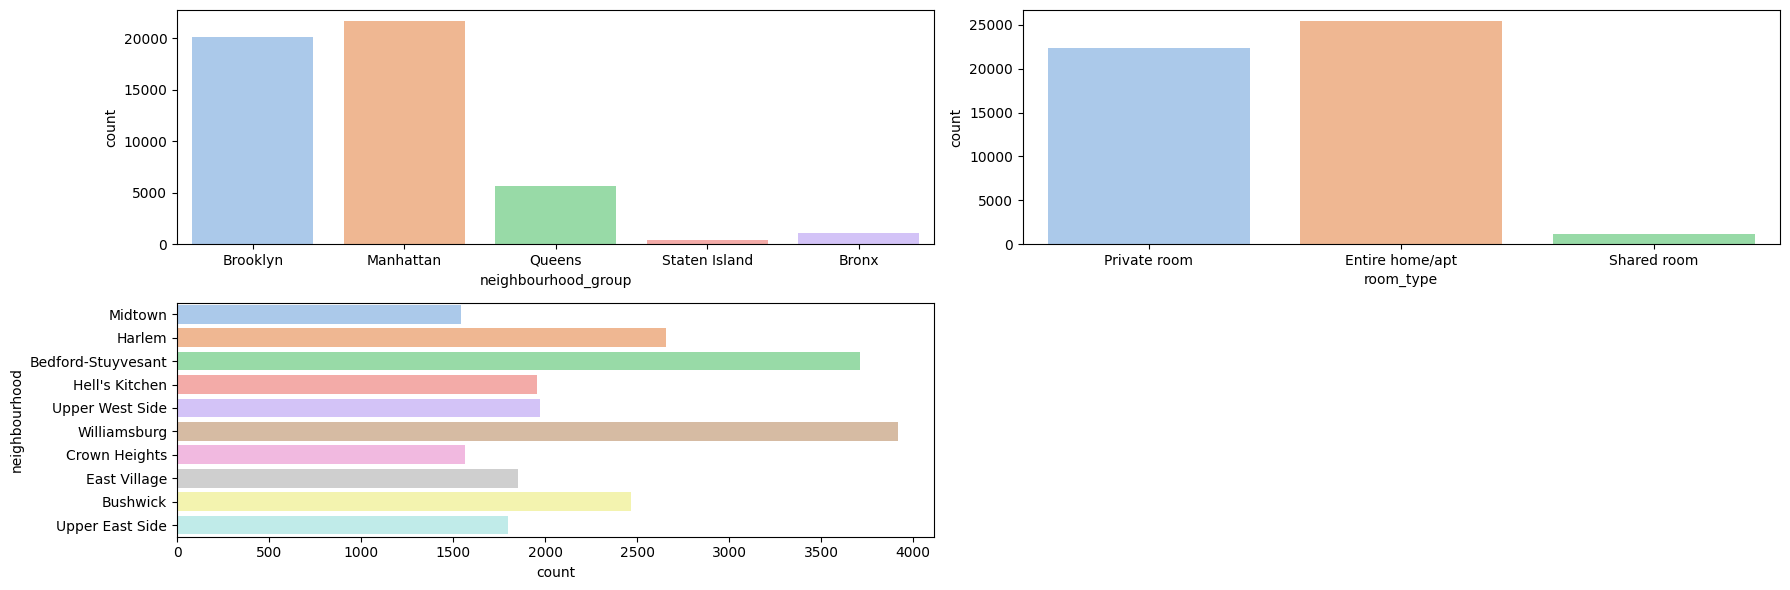

In [37]:
#--------------------------------Visualización de datos de variables categóricas-------------
#seleccion de top 10 de neighbouhood
top_neighbourhood=df["neighbourhood"].value_counts().head(10).index

df_top = df[df["neighbourhood"].isin(top_neighbourhood)]

#script para los 3 gráficos, barras 
fig, axis = plt.subplots(2, 2, figsize = (18, 6))

sns.countplot(ax = axis[0,0], data = df, x = "neighbourhood_group", palette='pastel',hue="neighbourhood_group" ,legend=False)
sns.countplot(ax = axis[0,1], data = df, x = "room_type", palette='pastel',hue="room_type",legend=False)
sns.countplot(ax = axis[1,0], data = df_top, y = "neighbourhood",  palette='pastel', hue="neighbourhood",legend=False)

fig.delaxes(axis[1, 1])
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Conclusiones de variables categóricas:
- Neighbourhood_grupo:
    - Manhattan y Brooklyn tienen la mayor concentración de alquileres que en las demás zonas.
- Room_type:
    - Existe alta oferta en alquileres de tipo entire home/apt y private_room.
    - Hay baja oferta en habitaciones compartidas.

- Neighbourhood:
    - Dentro edl top 10 de neighbourhood Williamsburg y Bedford-Stuyvesant destacan como los barrios con mayor oferta.



4.2. Análisis sobre variables numéricas

In [ ]:
#valores estadísticos de variables númericas
df[["price", "minimum_nights","availability_365","number_of_reviews"]].describe()

,price,minimum_nights,availability_365,number_of_reviews
count,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,112.781327,23.274466
std,240.154170,20.510550,131.622289,44.550582
min,0.000000,1.000000,0.000000,0.000000
25%,69.000000,1.000000,0.000000,1.000000
50%,106.000000,3.000000,45.000000,5.000000
75%,175.000000,5.000000,227.000000,24.000000
max,10000.000000,1250.000000,365.000000,629.000000


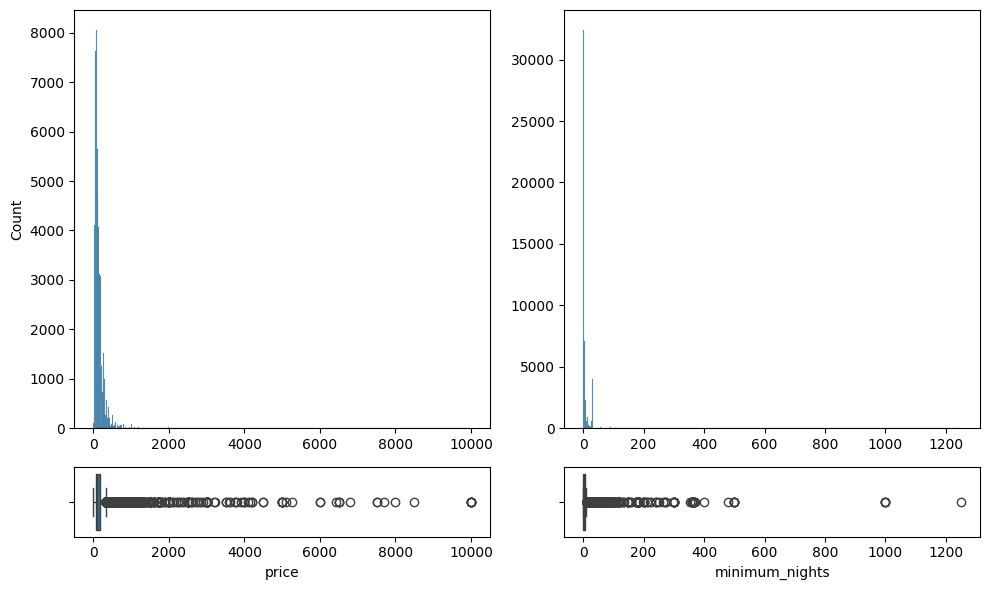

In [39]:
# ---------------------------Análisis sobre variables numéricas
fig, axis = plt.subplots(2,2, figsize = (10, 6), gridspec_kw={'height_ratios': [6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja

#visualización de price
sns.histplot(ax = axis[0,0], data = df, x = "price").set(xlabel = None)
sns.boxplot(ax = axis[1,0], data = df, x = "price")

#visualización de minimun nights
sns.histplot(ax = axis[0, 1], data = df, x = "minimum_nights").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "minimum_nights")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Análisis numéricas:

En este caso se evalúa la distribución de price y minimun nights.
price:
- Se visualiza muchísimos outliers en price, el valor máximo es 10000 y la media de este campo es 152.7
- Se evidencia que hay propiedades que tienen precio 0, esto se puede interpretar que hay errores de registro o valores imputados en lugar de nulos.
- 152.7>106, price tiene sesgo hacia la derecha, ya que la media es mayor a la mediana

minimun_nights:
- Se visualizan muchísimos outliers en minimun nights.
- La media es aprox. 7 noches y la mediana es 3, por lo que lo que se interpreta que mayormente los alquileres están destinado para estancias cortas. Sin embargo hay valor atípicos (1250), lo que quiere decir que esto puede suceder por alguna configuración adhoc correspondiente al alquiler de la propiedad. Además los outliers influyen en la media.
- No se evidencian valores 0, el valor mínimo es 1, por lo cual se puede decir que hay propiedades que se alquilan mínimo una noche.
- 7>3, minimun_nights tiene sesgo hacia la derecha, ya que la media es mayor a la mediana.


nota de sesgo:
Si media > mediana → sesgo a la derecha
Si media < mediana → sesgo a la izquierda

5. ANÁLISIS MULTIVARIANTE

5.1. Análisis numérico-numérico

Price- minimun_nights

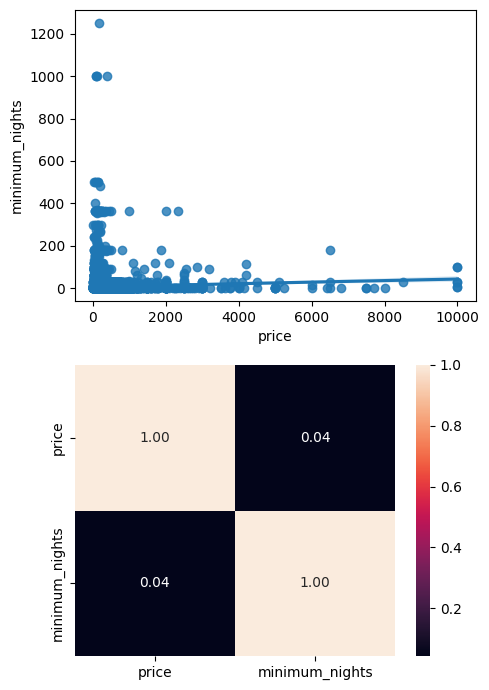

In [ ]:
#price-minimum_nights
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltipleS
sns.regplot(ax = axis[0], data = df, x = "price", y = "minimum_nights")
sns.heatmap(df[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()


- Se visualiza que hay correlación muy debil entre price y minimun_nights ya que el valor en el mapa de calor es 0.04, no es un valor cercano a 1.
- Por otro lado, en el gráfico de dispersión se evidencia la concentración de datos en valores bajos y muchos valores atípicos.

Price- availability_365

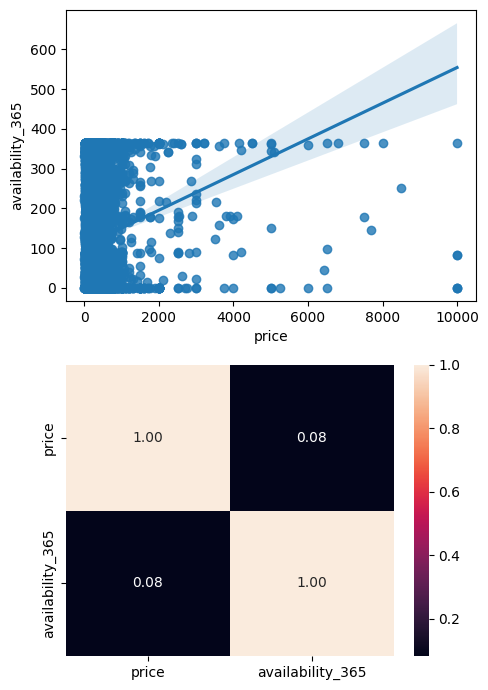

In [43]:
#price-availability_365
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltiples
sns.regplot(ax = axis[0], data = df, x = "price", y = "availability_365")
sns.heatmap(df[["price", "availability_365"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Se visualiza que hay correlación muy debil entre price y availability_365 ya que el valor en el mapa de calor es 0.08, no es un valor cercano a 1.
- El diagrama de dispersión presenta una tendencia ascendente, existe una alta dispersión y presencia de valores atípicos.

Price- number_of_reviews

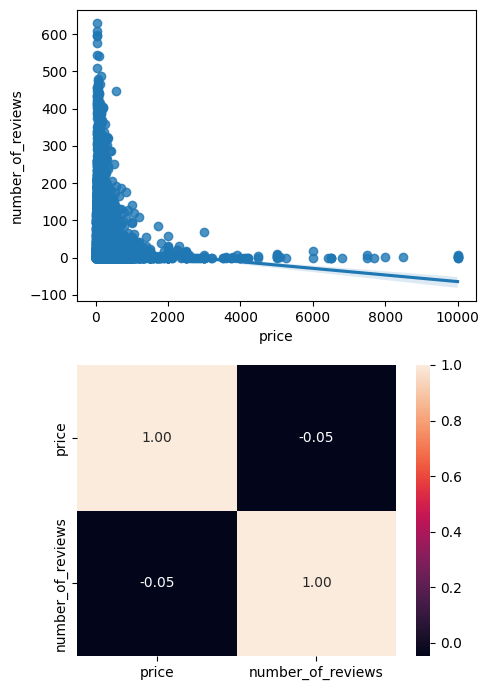

In [45]:
#price-number_of_reviews
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltiples
sns.regplot(ax = axis[0], data = df, x = "price", y = "number_of_reviews")
sns.heatmap(df[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Se visualiza que hay correlación muy debil entre price y number_of_reviews ya que el valor en el mapa de calor es 0.05, no es un valor cercano a 1.
- El diagrama de dispersión presenta una ligera tendencia descendente, existe una alta dispersión y presencia de valores atípicos. Además, se ve que los alojamientos con precio bajos presentan más cantidad de reviews. Por último, la dispersión de los datos hacen díficil encontrar una relación lineal entre las variables.

5.2. Análisis categórico- categórico